# Analytics Formatter — Chart Prototypes
Прототипы графиков для `analytics_fmt.py


In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from io import BytesIO
from datetime import datetime, timedelta
from IPython.display import Image, display


STYLE = {
    'bg':        '#1a1a2e',   
    'bg_axes':   '#16213e',  
    'green':     '#00d4aa', 
    'red':       '#ff4757',  
    'blue':      '#3d84ff',   
    'text':      '#e0e0e0',   
    'grid':      '#2a2a4a',  
}

def apply_style(fig, ax):
    fig.patch.set_facecolor(STYLE['bg'])
    ax.set_facecolor(STYLE['bg_axes'])
    ax.tick_params(colors=STYLE['text'], labelsize=9)
    ax.xaxis.label.set_color(STYLE['text'])
    ax.yaxis.label.set_color(STYLE['text'])
    ax.title.set_color(STYLE['text'])
    ax.grid(color=STYLE['grid'], linewidth=0.5, alpha=0.7)
    for spine in ax.spines.values():
        spine.set_edgecolor(STYLE['grid'])

def to_image(fig) -> BytesIO:
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)
    return buf


Style loaded ✅


Cumulative PnL — `plot_cumulative_pnl`

Показывает как растёт (или падает) прибыль стратегии.

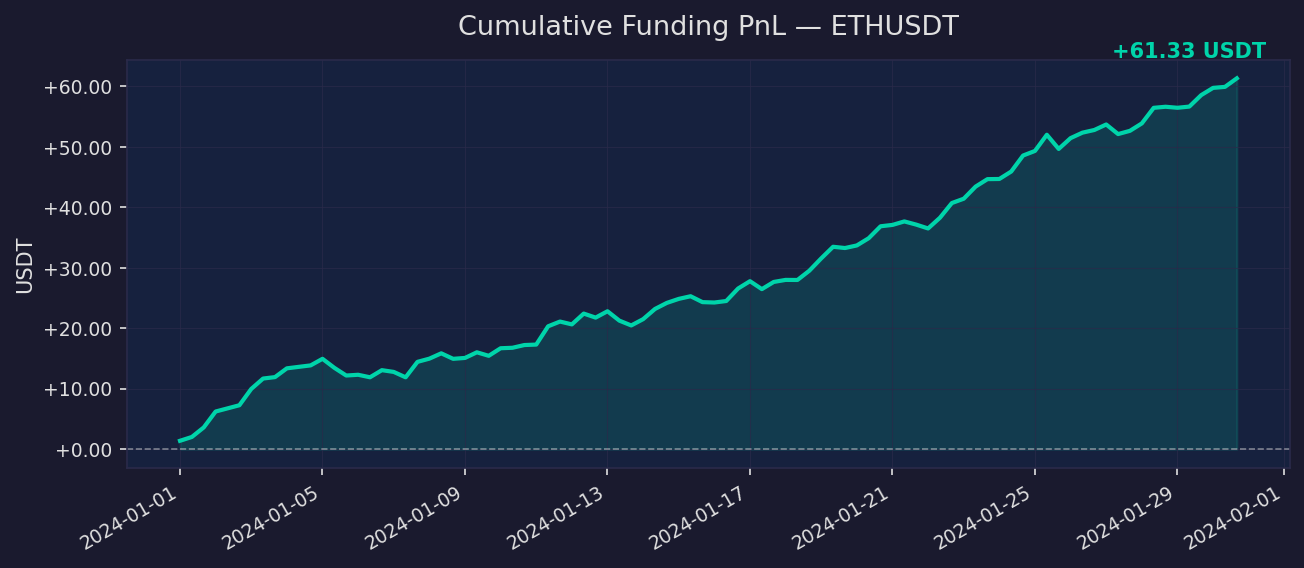

In [ ]:

np.random.seed(42)
n = 90
dates = [datetime(2024, 1, 1) + timedelta(hours=8*i) for i in range(n)]
cashflows = np.random.normal(0.8, 1.2, n)
cumulative = np.cumsum(cashflows)

mock_cashflow = pd.DataFrame({'funding_time': dates, 'cumulative_cashflow': cumulative})

# --- Функция ---
def plot_cumulative_pnl(data: pd.DataFrame, symbol: str) -> BytesIO:
    fig, ax = plt.subplots(figsize=(10, 4))
    apply_style(fig, ax)

    x = data['funding_time']
    y = data['cumulative_cashflow'].astype(float)


    final_color = STYLE['green'] if y.iloc[-1] >= 0 else STYLE['red']
    ax.plot(x, y, color=final_color, linewidth=2)
    ax.fill_between(x, y, 0,
                    where=(y >= 0), color=STYLE['green'], alpha=0.15)
    ax.fill_between(x, y, 0,
                    where=(y < 0),  color=STYLE['red'],   alpha=0.15)


    ax.axhline(0, color=STYLE['text'], linewidth=0.8, linestyle='--', alpha=0.5)


    last_val = y.iloc[-1]
    ax.annotate(f'{last_val:+.2f} USDT',
                xy=(x.iloc[-1], last_val),
                color=final_color, fontsize=10, fontweight='bold',
                xytext=(-60, 10), textcoords='offset points')

    ax.set_title(f'Cumulative Funding PnL — {symbol}', fontsize=13, pad=12)
    ax.set_ylabel('USDT', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.2f'))
    fig.autofmt_xdate()

    return to_image(fig)

buf = plot_cumulative_pnl(mock_cashflow, 'ETHUSDT')
display(Image(buf.read()))

Funding Rate History — `plot_funding_history`
Видно периоды положительного и отрицательного funding.

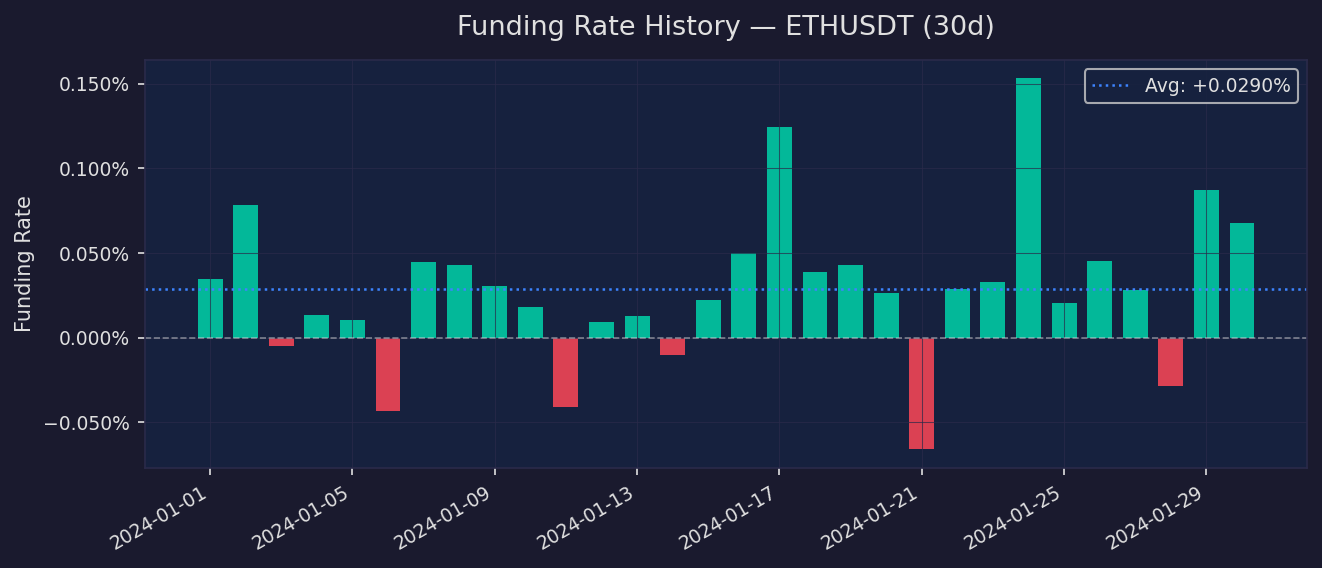

In [ ]:

dates_d = [datetime(2024, 1, 1) + timedelta(days=i) for i in range(30)]
rates = np.random.normal(0.0003, 0.0005, 30)
mock_funding = pd.DataFrame({'date': dates_d, 'funding_mean': rates})


def plot_funding_history(data: pd.DataFrame, symbol: str) -> BytesIO:
    fig, ax = plt.subplots(figsize=(10, 4))
    apply_style(fig, ax)

    x = data['date']
    y = data['funding_mean'].astype(float)
    colors = [STYLE['green'] if v >= 0 else STYLE['red'] for v in y]

    ax.bar(x, y, color=colors, alpha=0.85, width=0.7)
    ax.axhline(0, color=STYLE['text'], linewidth=0.8, linestyle='--', alpha=0.5)

    mean_val = y.mean()
    ax.axhline(mean_val, color=STYLE['blue'], linewidth=1.2,
               linestyle=':', label=f'Avg: {mean_val:+.4%}')
    ax.legend(facecolor=STYLE['bg_axes'], labelcolor=STYLE['text'], fontsize=9)

    ax.set_title(f'Funding Rate History — {symbol} (30d)', fontsize=13, pad=12)
    ax.set_ylabel('Funding Rate', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=3))
    fig.autofmt_xdate()

    return to_image(fig)

buf = plot_funding_history(mock_funding, 'ETHUSDT')
display(Image(buf.read()))

Basis History — `plot_basis_history`

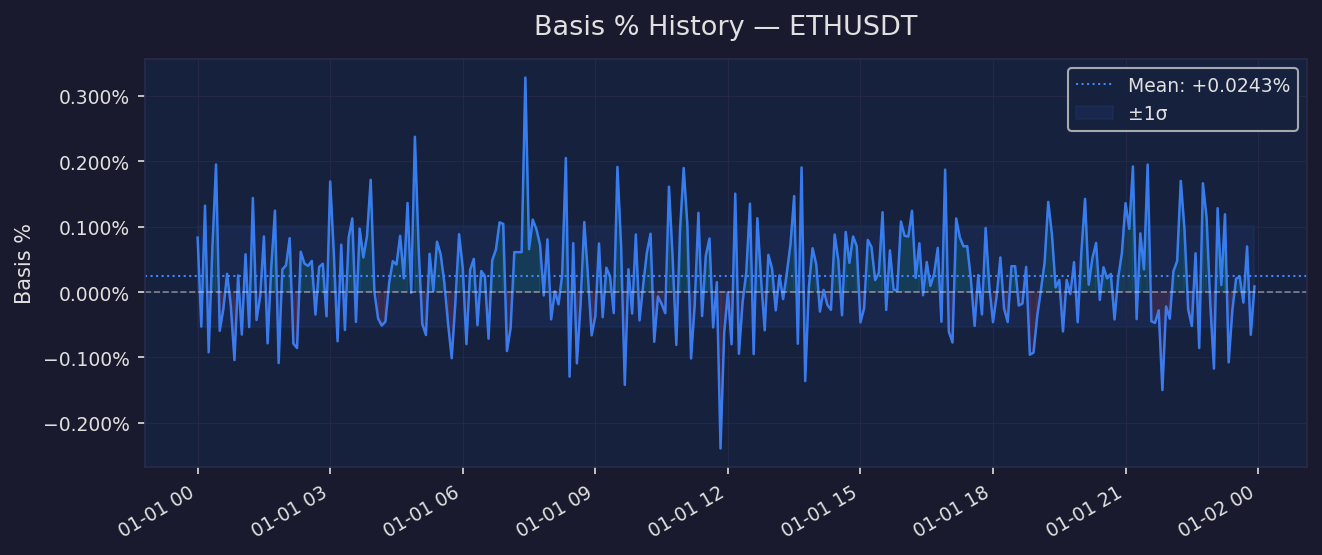

In [ ]:

dates_h = [datetime(2024, 1, 1) + timedelta(minutes=i) for i in range(0, 1440, 5)]
basis = np.random.normal(0.0002, 0.0008, len(dates_h))
mock_basis = pd.DataFrame({'minute_ts': dates_h, 'basis_pct_avg': basis})


def plot_basis_history(data: pd.DataFrame, symbol: str) -> BytesIO:
    fig, ax = plt.subplots(figsize=(10, 4))
    apply_style(fig, ax)

    x = data['minute_ts']
    y = data['basis_pct_avg'].astype(float)

    ax.plot(x, y, color=STYLE['blue'], linewidth=1.2, alpha=0.9)
    ax.fill_between(x, y, 0,
                    where=(y >= 0), color=STYLE['green'], alpha=0.12)
    ax.fill_between(x, y, 0,
                    where=(y < 0),  color=STYLE['red'],   alpha=0.12)
    ax.axhline(0, color=STYLE['text'], linewidth=0.8, linestyle='--', alpha=0.5)

    mean_v = y.mean()
    std_v  = y.std()
    ax.axhline(mean_v, color=STYLE['blue'], linewidth=1,
               linestyle=':', label=f'Mean: {mean_v:+.4%}')
    ax.fill_between(x, mean_v - std_v, mean_v + std_v,
                    color=STYLE['blue'], alpha=0.07, label=f'±1σ')
    ax.legend(facecolor=STYLE['bg_axes'], labelcolor=STYLE['text'], fontsize=9)

    ax.set_title(f'Basis % History — {symbol}', fontsize=13, pad=12)
    ax.set_ylabel('Basis %', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=3))
    fig.autofmt_xdate()

    return to_image(fig)

buf = plot_basis_history(mock_basis, 'ETHUSDT')
display(Image(buf.read()))

`plot_top_funding_symbols`
Горизонтальный бар-чарт топ символов по среднему funding rate.

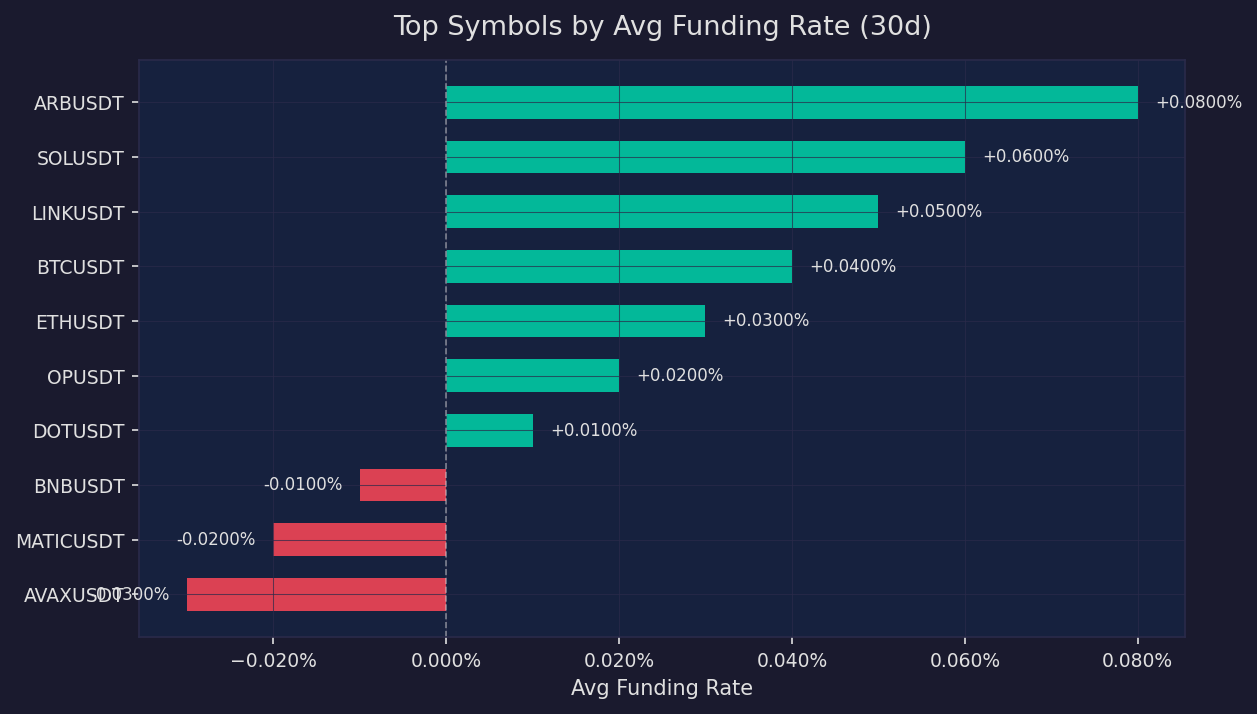

In [ ]:

mock_top = pd.DataFrame({
    'symbol': ['BTCUSDT','ETHUSDT','SOLUSDT','BNBUSDT','ARBUSDT',
               'OPUSDT','AVAXUSDT','DOTUSDT','LINKUSDT','MATICUSDT'],
    'avg_funding': [0.0004, 0.0003, 0.0006, -0.0001, 0.0008,
                    0.0002, -0.0003, 0.0001, 0.0005, -0.0002],
})


def plot_top_funding_symbols(data: pd.DataFrame) -> BytesIO:
    data = data.sort_values('avg_funding', ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    apply_style(fig, ax)

    colors = [STYLE['green'] if v >= 0 else STYLE['red']
              for v in data['avg_funding']]

    bars = ax.barh(data['symbol'], data['avg_funding'].astype(float),
                   color=colors, alpha=0.85, height=0.6)

    for bar, val in zip(bars, data['avg_funding']):
        offset = 0.00002 if val >= 0 else -0.00002
        ha = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height()/2,
                f'{val:+.4%}', va='center', ha=ha,
                color=STYLE['text'], fontsize=8)

    ax.axvline(0, color=STYLE['text'], linewidth=0.8, linestyle='--', alpha=0.5)
    ax.set_title('Top Symbols by Avg Funding Rate (30d)', fontsize=13, pad=12)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=3))
    ax.set_xlabel('Avg Funding Rate', fontsize=10)

    return to_image(fig)

buf = plot_top_funding_symbols(mock_top)
display(Image(buf.read()))

`plot_pnl_breakdown`
Структура PnL — из чего складывается итог: price funding fees

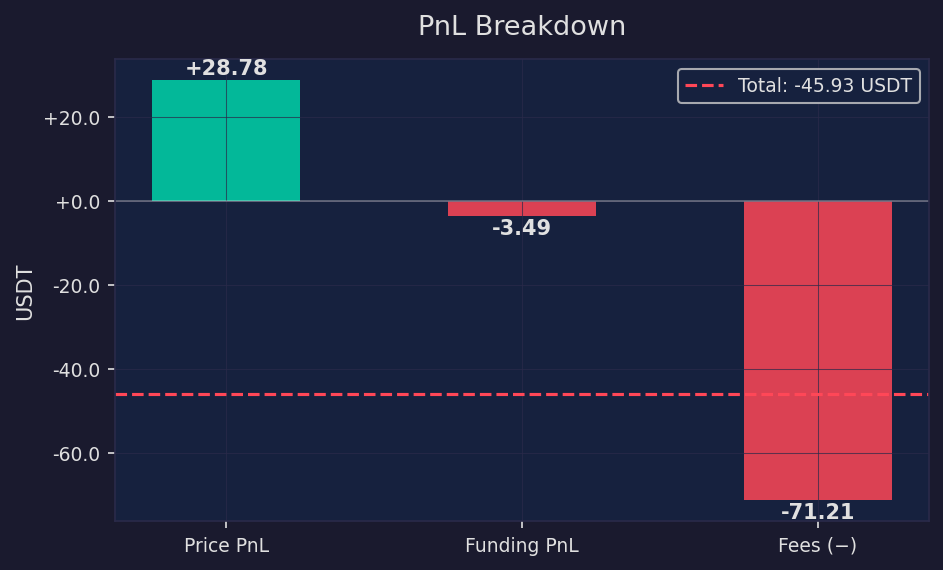

In [ ]:

mock_pnl = {
    'total_price_pnl':   28.78,
    'total_funding_pnl': -3.49,
    'total_fees':        71.21,
    'total_pnl':         -45.93,
}


def plot_pnl_breakdown(data: dict) -> BytesIO:
    labels = ['Price PnL', 'Funding PnL', 'Fees (−)']
    values = [
        float(data['total_price_pnl']),
        float(data['total_funding_pnl']),
        -abs(float(data['total_fees'])),   
    ]
    colors = [STYLE['green'] if v >= 0 else STYLE['red'] for v in values]

    fig, ax = plt.subplots(figsize=(7, 4))
    apply_style(fig, ax)

    bars = ax.bar(labels, values, color=colors, alpha=0.85, width=0.5)


    for bar, val in zip(bars, values):
        offset = 0.5 if val >= 0 else -0.5
        va = 'bottom' if val >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2, val + offset,
                f'{val:+.2f}', ha='center', va=va,
                color=STYLE['text'], fontsize=10, fontweight='bold')

    total = float(data['total_pnl'])
    total_color = STYLE['green'] if total >= 0 else STYLE['red']
    ax.axhline(total, color=total_color, linewidth=1.5,
               linestyle='--', label=f'Total: {total:+.2f} USDT')
    ax.legend(facecolor=STYLE['bg_axes'], labelcolor=STYLE['text'], fontsize=9)

    ax.axhline(0, color=STYLE['text'], linewidth=0.8, alpha=0.4)
    ax.set_title('PnL Breakdown', fontsize=13, pad=12)
    ax.set_ylabel('USDT', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.1f'))

    return to_image(fig)

buf = plot_pnl_breakdown(mock_pnl)
display(Image(buf.read()))